# 01 — Data Audit and Exploratory Data Analysis

## Objectives

This notebook will:

1. Verify the dataset's real dimensions and schema.
2. Investigate possible Excel export truncation.
3. Measure timestamp and city coverage.
4. Detect missing values, duplicates, invalid values, and temporal gaps.
5. Determine whether seasonal analysis is defensible.
6. examine provisional AQI class balance.
7. Recommend Dhaka plus 2–4 cities for the project.

No preprocessing or modeling is performed in this notebook.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Environment and Project Setup

This section prepares the Google Colab environment for the audit.

It:

- Mounts Google Drive so the raw dataset and generated outputs remain available after the Colab runtime ends.
- Clones the GitHub repository if it is not already present.
- Pulls the newest version of the selected Git branch.
- Creates separate folders for raw data, audit outputs, and figures.
- Imports the libraries required for data analysis and visualization.
- Sets a fixed random seed to make sampling and plots reproducible.

No dataset is modified during this step.

In [2]:
from pathlib import Path
from IPython.display import display

import hashlib
import json
import os
import re
import subprocess
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

REPO_NAME = "cse437-air-quality-group-18"
REPO_URL = "https://github.com/ArafUlHaque/cse437-air-quality-group-18.git"
GIT_BRANCH = "main"

os.chdir("/content")
REPO_DIR = Path("/content") / REPO_NAME

if REPO_DIR.is_dir():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", GIT_BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", GIT_BRANCH], check=True)
else:
    subprocess.run(["git", "clone", "--branch", GIT_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

STORAGE_ROOT = Path("/content/drive/MyDrive/CSE437_air_quality_group_18")
RAW_DIR = STORAGE_ROOT / "raw"
PROCESSED_DIR = STORAGE_ROOT / "processed"
AUDIT_DIR = PROCESSED_DIR / "notebook_01_audit"
FIGURES_DIR = STORAGE_ROOT / "figures" / "notebook_01"

RAW_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Repository:", REPO_DIR)
print("Raw data:", RAW_DIR)
print("Audit outputs:", AUDIT_DIR)
print("Figures:", FIGURES_DIR)

Repository: /content/cse437-air-quality-group-18
Raw data: /content/drive/MyDrive/CSE437_air_quality_group_18/raw
Audit outputs: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_01_audit
Figures: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_01


## 2. Raw Dataset Identification and Integrity Check

This section selects `AQI Bangladesh.csv` as the main hourly air-quality dataset.

The filename is specified explicitly because the raw-data folder also contains `cities.csv`. The code verifies that the main file exists and calculates its file size and SHA-256 checksum for reproducibility.

In [3]:
RAW_FILE_NAME = "AQI Bangladesh.csv"

if RAW_FILE_NAME:
    RAW_FILE = RAW_DIR / RAW_FILE_NAME

    if not RAW_FILE.is_file():
        raise FileNotFoundError(f"File not found: {RAW_FILE}")
else:
    csv_files = sorted(RAW_DIR.glob("*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV file found in {RAW_DIR}")

    if len(csv_files) > 1:
        print("Multiple CSV files found:")

        for file in csv_files:
            print("-", file.name)

        raise ValueError("Set RAW_FILE_NAME to the correct source filename.")

    RAW_FILE = csv_files[0]

def calculate_sha256(file_path):
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

file_size_mb = RAW_FILE.stat().st_size / (1024 ** 2)
file_checksum = calculate_sha256(RAW_FILE)

print("Source file:", RAW_FILE.name)
print(f"File size: {file_size_mb:,.2f} MB")
print("SHA-256:", file_checksum)

Source file: AQI Bangladesh.csv
File size: 93.75 MB
SHA-256: 8760175fc048eea4180b828fd60d10cb799a73a5144a7e4aca19ddbaf8dbdd62


## 3. Loading and Initial Inspection

This section loads the raw CSV file into a pandas DataFrame without changing the source file.

It displays:

- The total number of rows and columns
- The first and last records
- The original column names
- Each column's data type
- The number of non-missing values
- The approximate memory usage

This initial inspection helps identify unexpected columns, data types, and file-loading problems before the detailed audit begins.

In [4]:
df_raw = pd.read_csv(RAW_FILE, low_memory=False)

print("Dataset loaded.")
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]:,}")

display(df_raw.head())
display(df_raw.tail())

Dataset loaded.
Rows: 1,048,551
Columns: 13


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0,16.7,252.0,NaN,18.6,5.2,13.0,50.0
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5,12.3,249.0,NaN,18.5,5.7,19.0,50.0
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1,10.9,244.0,NaN,18.4,6.5,27.0,51.0
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4,10.3,233.0,NaN,17.2,6.9,39.0,51.0
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8,11.3,217.0,NaN,14.8,6.2,51.0,51.0


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
1048546,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T10:00,13.5,8.2,145.0,NaN,1.5,0.9,69.0,52.0
1048547,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T11:00,14.0,8.6,157.0,NaN,2.5,1.1,65.0,51.0
1048548,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T12:00,19.4,12.1,188.0,NaN,4.6,1.3,55.0,51.0
1048549,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T13:00,22.2,13.9,203.0,NaN,4.9,1.4,53.0,50.0
1048550,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T14:00,24.0,15.1,224.0,NaN,5.3,1.6,51.0,49.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [5]:
print("Original column names:")
for index, column in enumerate(df_raw.columns, start=1):
    print(f"{index:>2}. {column}")

print()
df_raw.info()

Original column names:
 1. city_id
 2. city_name
 3. lat
 4. lon
 5. datetime
 6. pm10
 7. pm2_5
 8. carbon_monoxide
 9. carbon_dioxide
10. nitrogen_dioxide
11. sulphur_dioxide
12. ozone
13. aqi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048551 entries, 0 to 1048550
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   city_id           1048551 non-null  int64  
 1   city_name         1048551 non-null  object 
 2   lat               1048551 non-null  float64
 3   lon               1048551 non-null  float64
 4   datetime          1048551 non-null  object 
 5   pm10              1048551 non-null  float64
 6   pm2_5             1048551 non-null  float64
 7   carbon_monoxide   1048551 non-null  float64
 8   carbon_dioxide    274224 non-null   float64
 9   nitrogen_dioxide  1048551 non-null  float64
 10  sulphur_dioxide   1048551 non-null  float64
 11  ozone             1048551 non-null  float64
 12  

## 4. Schema Detection and Column Mapping

The published description identifies the expected variables, but the code does not assume that the CSV uses a particular spelling or capitalization.

This section:

1. Standardizes column names temporarily for comparison.
2. Searches for possible names such as `City`, `city_name`, `Timestamp`, `PM2.5`, and `AQI`.
3. Maps the detected source columns to consistent internal names.
4. Displays the mapping so that no column is renamed silently.
5. Stops execution if the required city, timestamp, or AQI columns cannot be identified.

The original raw DataFrame remains unchanged.


In [6]:
def normalize_column_name(column):
    column = unicodedata.normalize("NFKC", str(column)).lower()
    column = column.replace("2.5", "25")
    column = re.sub(r"[^a-z0-9]+", "_", column)
    return column.strip("_")

ALIASES = {
    "city_id": ["city_id", "location_id", "station_id"],
    "city": ["city", "city_name", "location", "location_name", "station", "station_name"],
    "latitude": ["latitude", "lat"],
    "longitude": ["longitude", "longitude_value", "lon", "lng"],
    "timestamp": ["timestamp", "date_time", "datetime", "time", "date"],
    "pm10": ["pm10", "pm_10"],
    "pm25": ["pm25", "pm_25", "pm2_5"],
    "co": ["co", "carbon_monoxide"],
    "co2": ["co2", "carbon_dioxide"],
    "no2": ["no2", "nitrogen_dioxide"],
    "so2": ["so2", "sulfur_dioxide", "sulphur_dioxide"],
    "o3": ["o3", "ozone"],
    "aqi": ["aqi", "air_quality_index"],
}

normalized_columns = {}

for column in df_raw.columns:
    normalized = normalize_column_name(column)

    if normalized in normalized_columns:
        raise ValueError(f"Column-name collision: {column} and {normalized_columns[normalized]}")

    normalized_columns[normalized] = column

column_mapping = {}

for canonical, aliases in ALIASES.items():
    for alias in aliases:
        normalized_alias = normalize_column_name(alias)

        if normalized_alias in normalized_columns:
            column_mapping[canonical] = normalized_columns[normalized_alias]
            break

mapping_table = pd.DataFrame({
    "canonical_name": list(ALIASES),
    "source_column": [column_mapping.get(column, "NOT FOUND") for column in ALIASES],
})

display(mapping_table)

required_columns = ["city", "timestamp", "aqi"]
missing_required = [column for column in required_columns if column not in column_mapping]

if missing_required:
    raise ValueError(f"Required columns not found: {missing_required}")

audit = df_raw.rename(columns={source: canonical for canonical, source in column_mapping.items()}).copy()

print("Required columns found successfully.")

,canonical_name,source_column
0,city_id,city_id
1,city,city_name
2,latitude,lat
3,longitude,lon
4,timestamp,datetime
5,pm10,pm10
6,pm25,pm2_5
7,co,carbon_monoxide
8,co2,carbon_dioxide
9,no2,nitrogen_dioxide


Required columns found successfully.


## 5. Timestamp and Numeric Type Conversion

This section converts the detected columns into types suitable for auditing.

It:

- Removes accidental spaces from city names.
- Preserves a copy of the original timestamp text.
- Parses timestamps into a consistent datetime representation.
- Converts pollutant, AQI, latitude, and longitude columns to numeric values.
- Counts values that could not be converted successfully.
- Displays examples of the original and parsed timestamps.

Timestamps are temporarily normalized to UTC for consistent auditing. The source timezone must still be confirmed before the final daily aggregation in Notebook 02.

In [7]:
audit["city"] = audit["city"].astype("string").str.strip()
audit.loc[audit["city"].eq(""), "city"] = pd.NA

audit["timestamp_raw"] = audit["timestamp"].astype("string")

try:
    audit["timestamp"] = pd.to_datetime(audit["timestamp_raw"], errors="coerce", format="mixed", utc=True)
except ValueError:
    audit["timestamp"] = pd.to_datetime(audit["timestamp_raw"], errors="coerce", utc=True)

numeric_columns = [
    column
    for column in ["latitude", "longitude", "pm10", "pm25", "co", "co2", "no2", "so2", "o3", "aqi"]
    if column in audit.columns
]

numeric_parse_failures = {}

for column in numeric_columns:
    original_non_missing = audit[column].notna()
    converted = pd.to_numeric(audit[column], errors="coerce")

    numeric_parse_failures[column] = int((original_non_missing & converted.isna()).sum())
    audit[column] = converted

timestamp_examples = audit[["timestamp_raw", "timestamp"]].head(10)
display(timestamp_examples)

print("Unparseable timestamps:", audit["timestamp"].isna().sum())
print("Numeric parsing failures:")
display(pd.Series(numeric_parse_failures, name="parse_failures").to_frame())

,timestamp_raw,timestamp
0,2022-08-05T00:00,2022-08-05 00:00:00+00:00
1,2022-08-05T01:00,2022-08-05 01:00:00+00:00
2,2022-08-05T02:00,2022-08-05 02:00:00+00:00
3,2022-08-05T03:00,2022-08-05 03:00:00+00:00
4,2022-08-05T04:00,2022-08-05 04:00:00+00:00
5,2022-08-05T05:00,2022-08-05 05:00:00+00:00
6,2022-08-05T06:00,2022-08-05 06:00:00+00:00
7,2022-08-05T07:00,2022-08-05 07:00:00+00:00
8,2022-08-05T08:00,2022-08-05 08:00:00+00:00
9,2022-08-05T09:00,2022-08-05 09:00:00+00:00


Unparseable timestamps: 0
Numeric parsing failures:


,parse_failures
latitude,0
longitude,0
pm10,0
pm25,0
co,0
co2,0
no2,0
so2,0
o3,0
aqi,0


## 6. Dataset Arithmetic and Possible Truncation Audit

The dataset page claims hourly observations for 103 cities across approximately 25 years. This section checks whether the published row count is mathematically consistent with that claim.

It compares:

- The actual and published row counts
- The actual and published city counts
- The approximate number of rows expected from complete 25-year hourly coverage
- The observed percentage of that theoretical total
- The equivalent number of complete years per city
- The dataset row count against Microsoft Excel's maximum row limit

A warning is printed if the row count is unusually close to Excel's limit, because this may indicate that the published CSV was truncated during export.

In [8]:
PUBLISHED_ROWS = 1_048_551
PUBLISHED_CITIES = 103
PUBLISHED_YEARS = 25

EXCEL_TOTAL_ROW_LIMIT = 1_048_576
EXCEL_DATA_ROW_LIMIT = EXCEL_TOTAL_ROW_LIMIT - 1

actual_rows = len(audit)
actual_cities = audit["city"].nunique(dropna=True)

theoretical_rows = int(PUBLISHED_CITIES * PUBLISHED_YEARS * 365.25 * 24)
equivalent_years_per_city = actual_rows / (max(actual_cities, 1) * 365.25 * 24)
distance_from_excel_limit = EXCEL_DATA_ROW_LIMIT - actual_rows

arithmetic_audit = pd.DataFrame({
    "check": [
        "Actual rows",
        "Published rows",
        "Actual cities",
        "Published cities",
        "Approximate rows for complete 25-year hourly coverage",
        "Observed rows as percentage of theoretical rows",
        "Equivalent complete years per observed city",
        "Maximum Excel data rows with one header",
        "Rows below Excel data-row limit",
    ],
    "value": [
        actual_rows,
        PUBLISHED_ROWS,
        actual_cities,
        PUBLISHED_CITIES,
        theoretical_rows,
        100 * actual_rows / theoretical_rows,
        equivalent_years_per_city,
        EXCEL_DATA_ROW_LIMIT,
        distance_from_excel_limit,
    ],
})

display(arithmetic_audit)

if abs(distance_from_excel_limit) <= 100:
    print("WARNING: The row count is extremely close to Excel's data-row limit.")
else:
    print("The row count is not within 100 rows of Excel's data-row limit.")

,check,value
0,Actual rows,1.048551e+06
1,Published rows,1.048551e+06
2,Actual cities,3.000000e+01
3,Published cities,1.030000e+02
4,Approximate rows for complete 25-year hourly c...,2.257245e+07
5,Observed rows as percentage of theoretical rows,4.645269e+00
6,Equivalent complete years per observed city,3.987189e+00
7,Maximum Excel data rows with one header,1.048575e+06
8,Rows below Excel data-row limit,2.400000e+01


## 7. General Data-Quality Audit

This section investigates common data-quality problems without removing or correcting any records.

The checks include:

- Missing city values
- Unparseable timestamps
- Completely duplicated rows
- Repeated city–timestamp combinations
- Missing values in every column
- Pollutant concentrations below zero
- AQI values outside the usual 0–500 range
- Geographic coordinates outside approximate Bangladesh boundaries

The range checks are diagnostic flags only. A flagged value is not automatically removed because each cleaning decision must be justified in Notebook 02.

In [9]:
exact_duplicate_rows = int(df_raw.duplicated().sum())

valid_city_time = audit.dropna(subset=["city", "timestamp"])
duplicate_city_timestamps = int(valid_city_time.duplicated(["city", "timestamp"]).sum())

quality_summary = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Missing city values",
        "Unparseable timestamps",
        "Exact duplicate rows",
        "Duplicate city-timestamp pairs",
    ],
    "count": [
        len(audit),
        audit.shape[1],
        audit["city"].isna().sum(),
        audit["timestamp"].isna().sum(),
        exact_duplicate_rows,
        duplicate_city_timestamps,
    ],
})

display(quality_summary)

,check,count
0,Rows,1048551
1,Columns,14
2,Missing city values,0
3,Unparseable timestamps,0
4,Exact duplicate rows,0
5,Duplicate city-timestamp pairs,0


In [10]:
missingness = pd.DataFrame({
    "dtype": audit.dtypes.astype(str),
    "missing_count": audit.isna().sum(),
    "missing_percent": audit.isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)

display(missingness)
missingness.to_csv(AUDIT_DIR / "overall_missingness.csv")

,dtype,missing_count,missing_percent
co2,float64,774327,73.847338
aqi,float64,696,0.066377
latitude,float64,0,0.000000
longitude,float64,0,0.000000
city_id,int64,0,0.000000
city,string,0,0.000000
pm10,float64,0,0.000000
timestamp,"datetime64[ns, UTC]",0,0.000000
co,float64,0,0.000000
pm25,float64,0,0.000000


In [11]:
range_checks = []

for column in ["pm10", "pm25", "co", "co2", "no2", "so2", "o3"]:
    if column in audit.columns:
        range_checks.append({
            "check": f"{column} below 0",
            "flagged_rows": int(audit[column].lt(0).sum()),
        })

range_checks.extend([
    {"check": "AQI below 0", "flagged_rows": int(audit["aqi"].lt(0).sum())},
    {"check": "AQI above 500", "flagged_rows": int(audit["aqi"].gt(500).sum())},
])

if "latitude" in audit.columns:
    range_checks.append({
        "check": "Latitude outside approximate Bangladesh bounds",
        "flagged_rows": int((audit["latitude"].notna() & ~audit["latitude"].between(20, 27)).sum()),
    })

if "longitude" in audit.columns:
    range_checks.append({
        "check": "Longitude outside approximate Bangladesh bounds",
        "flagged_rows": int((audit["longitude"].notna() & ~audit["longitude"].between(88, 93)).sum()),
    })

range_check_table = pd.DataFrame(range_checks)
display(range_check_table)

print("These are audit flags only. No rows are removed in Notebook 01.")

,check,flagged_rows
0,pm10 below 0,0
1,pm25 below 0,0
2,co below 0,0
3,co2 below 0,0
4,no2 below 0,1
5,so2 below 0,0
6,o3 below 0,11
7,AQI below 0,0
8,AQI above 500,0
9,Latitude outside approximate Bangladesh bounds,0


These are audit flags only. No rows are removed in Notebook 01.


## 8. Temporal Coverage by City

This section measures how much data is actually available for each city.

For every city, it calculates:

- Total rows
- Unique timestamps
- Unique recorded hours
- First and last timestamp
- Number of observed calendar days
- Total date span
- Expected hourly observations within that span
- Approximate hourly coverage percentage
- Median, minimum, and maximum recorded hours per day
- Percentage of non-missing AQI observations

The results are saved as `city_coverage_summary.csv`. This table will be one of the main sources of evidence for selecting Dhaka and 2–4 additional cities.

In [12]:
audit_valid = audit.dropna(subset=["city", "timestamp"]).copy()

audit_valid["hour"] = audit_valid["timestamp"].dt.floor("h")
audit_valid["date"] = audit_valid["timestamp"].dt.tz_convert(None).dt.normalize()

coverage = (
    audit_valid.groupby("city")
    .agg(
        row_count=("timestamp", "size"),
        unique_timestamps=("timestamp", "nunique"),
        unique_hours=("hour", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        observed_days=("date", "nunique"),
    )
    .reset_index()
)

coverage["span_days"] = (
    (coverage["last_timestamp"] - coverage["first_timestamp"]).dt.total_seconds() / 86400
) + 1

coverage["expected_hours_in_span"] = coverage["span_days"] * 24
coverage["hourly_coverage_percent"] = (
    100 * coverage["unique_hours"] / coverage["expected_hours_in_span"]
)

city_day_counts = (
    audit_valid.groupby(["city", "date"])
    .agg(
        row_count=("timestamp", "size"),
        unique_hours=("hour", "nunique"),
    )
    .reset_index()
)

daily_coverage = (
    city_day_counts.groupby("city")
    .agg(
        median_rows_per_day=("row_count", "median"),
        median_unique_hours_per_day=("unique_hours", "median"),
        minimum_unique_hours_per_day=("unique_hours", "min"),
        maximum_unique_hours_per_day=("unique_hours", "max"),
    )
    .reset_index()
)

aqi_completeness = (
    audit_valid.groupby("city")["aqi"]
    .apply(lambda values: 100 * values.notna().mean())
    .rename("aqi_non_missing_percent")
    .reset_index()
)

coverage = coverage.merge(daily_coverage, on="city", how="left")
coverage = coverage.merge(aqi_completeness, on="city", how="left")
coverage = coverage.sort_values("row_count", ascending=False).reset_index(drop=True)

display(coverage.head(25))
coverage.to_csv(AUDIT_DIR / "city_coverage_summary.csv", index=False)

,city,row_count,unique_timestamps,unique_hours,first_timestamp,last_timestamp,observed_days,span_days,expected_hours_in_span,hourly_coverage_percent,median_rows_per_day,median_unique_hours_per_day,minimum_unique_hours_per_day,maximum_unique_hours_per_day,aqi_non_missing_percent
0,Dhaka,227016,227016,227016,2000-01-01 00:00:00+00:00,2025-11-23 23:00:00+00:00,9459,9459.958333,227039.0,99.989870,24.0,24.0,24,24,99.989428
1,Badarganj,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
2,Bera,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
3,Barisāl,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
4,Bhairab Bāzār,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
5,Baniachang,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
6,Bogra,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
7,Bhola,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
8,Bhāndāria,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219
9,Bhātpāra Abhaynagar,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,1208.958333,29015.0,99.920731,24.0,24.0,24,24,99.917219


In [13]:
print("Overall recorded timestamp range")
print("Minimum:", audit_valid["timestamp"].min())
print("Maximum:", audit_valid["timestamp"].max())
print("Duration:", audit_valid["timestamp"].max() - audit_valid["timestamp"].min())

print()
print("Cities:", audit_valid["city"].nunique())
print("City-days:", len(city_day_counts))

Overall recorded timestamp range
Minimum: 2000-01-01 00:00:00+00:00
Maximum: 2025-11-23 23:00:00+00:00
Duration: 9458 days 23:00:00

Cities: 30
City-days: 43690


## 9. Pollutant Missingness by City

Overall missingness can hide serious city-specific problems. A pollutant may appear mostly complete across the entire dataset while being unavailable for a particular city.

This section calculates the percentage of missing values for each pollutant and AQI within every city.

The complete table is saved as `missingness_by_city.csv` and will help determine:

- Which cities have sufficient predictor data
- Which pollutants may require missing-value treatment
- Whether some cities should be excluded from the project

In [14]:
audit_columns = [
    column
    for column in ["pm10", "pm25", "co", "co2", "no2", "so2", "o3", "aqi"]
    if column in audit_valid.columns
]

missingness_by_city = (
    audit_valid.groupby("city")[audit_columns]
    .agg(lambda values: 100 * values.isna().mean())
    .round(2)
)

display(missingness_by_city.head(20))
missingness_by_city.to_csv(AUDIT_DIR / "missingness_by_city.csv")

,pm10,pm25,co,co2,no2,so2,o3,aqi
city,,,,,,,,
Azimpur,0.0,0.0,0.0,67.36,0.0,0.0,0.0,0.00
Badarganj,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Baniachang,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Barisāl,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bera,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhairab Bāzār,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bherāmāra,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhola,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhāndāria,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08


## 10. Temporal-Gap Audit

The dataset is described as hourly, so consecutive observations should generally be one hour apart.

This section examines the ordered timestamps of every city and calculates:

- The median time between observations
- The number of gaps longer than 1.5 hours
- The number of gaps longer than 24 hours
- The largest observed gap

Large or frequent gaps can make daily aggregation and next-day target construction unreliable. The complete results are saved as `city_gap_summary.csv`.

In [15]:
gap_records = []

for city, city_data in audit_valid.groupby("city"):
    timestamps = city_data["timestamp"].drop_duplicates().sort_values()
    differences = timestamps.diff().dt.total_seconds().div(3600).dropna()

    gap_records.append({
        "city": city,
        "median_interval_hours": differences.median(),
        "gaps_over_1_5_hours": int(differences.gt(1.5).sum()),
        "gaps_over_24_hours": int(differences.gt(24).sum()),
        "maximum_gap_hours": differences.max(),
    })

gap_summary = pd.DataFrame(gap_records)
gap_summary = gap_summary.sort_values("maximum_gap_hours", ascending=False)

display(gap_summary.head(25))
gap_summary.to_csv(AUDIT_DIR / "city_gap_summary.csv", index=False)

,city,median_interval_hours,gaps_over_1_5_hours,gaps_over_24_hours,maximum_gap_hours
0,Azimpur,1.0,0,0,1.0
1,Badarganj,1.0,0,0,1.0
2,Baniachang,1.0,0,0,1.0
3,Barisāl,1.0,0,0,1.0
4,Bera,1.0,0,0,1.0
5,Bhairab Bāzār,1.0,0,0,1.0
6,Bherāmāra,1.0,0,0,1.0
7,Bhola,1.0,0,0,1.0
8,Bhāndāria,1.0,0,0,1.0
9,Bhātpāra Abhaynagar,1.0,0,0,1.0


## 11. Seasonality Feasibility Assessment

A seasonal comparison is meaningful only when cities contain sufficiently complete observations across multiple seasons and years.

For this diagnostic assessment:

- A usable day must contain at least 18 unique recorded hours.
- A usable month must contain usable data for at least 80% of its calendar days.
- A city must have at least two complete usable years to support strong seasonal claims.

The code measures monthly and yearly completeness for every city. It then identifies whether each city's coverage is adequate for seasonal analysis.

If the selected cities do not meet these conditions, seasonal variation will not be retained as a primary research question.

In [16]:
MIN_HOURS_PER_DAY = 18
MIN_MONTHLY_DAY_COVERAGE = 0.80
MIN_COMPLETE_YEARS = 2

city_day_counts["usable_day"] = city_day_counts["unique_hours"].ge(MIN_HOURS_PER_DAY)
city_day_counts["year_month"] = city_day_counts["date"].dt.to_period("M")

monthly_coverage = (
    city_day_counts.groupby(["city", "year_month"])
    .agg(
        observed_days=("date", "nunique"),
        usable_days=("usable_day", "sum"),
    )
    .reset_index()
)

monthly_coverage["expected_days"] = monthly_coverage["year_month"].dt.days_in_month
monthly_coverage["usable_day_fraction"] = (
    monthly_coverage["usable_days"] / monthly_coverage["expected_days"]
)

monthly_coverage["usable_month"] = monthly_coverage["usable_day_fraction"].ge(
    MIN_MONTHLY_DAY_COVERAGE
)

monthly_coverage["year"] = monthly_coverage["year_month"].dt.year

yearly_coverage = (
    monthly_coverage.groupby(["city", "year"])
    .agg(
        months_present=("year_month", "nunique"),
        usable_months=("usable_month", "sum"),
    )
    .reset_index()
)

yearly_coverage["complete_usable_year"] = yearly_coverage["usable_months"].eq(12)

seasonality_summary = (
    yearly_coverage.groupby("city")
    .agg(
        years_present=("year", "nunique"),
        complete_usable_years=("complete_usable_year", "sum"),
    )
    .reset_index()
)

seasonality_summary["seasonality_supported"] = (
    seasonality_summary["complete_usable_years"] >= MIN_COMPLETE_YEARS
)

seasonality_summary = seasonality_summary.sort_values(
    ["complete_usable_years", "years_present"],
    ascending=False,
)

display(seasonality_summary.head(25))

monthly_coverage.to_csv(AUDIT_DIR / "monthly_coverage.csv", index=False)
seasonality_summary.to_csv(AUDIT_DIR / "seasonality_summary.csv", index=False)

,city,years_present,complete_usable_years,seasonality_supported
21,Dhaka,26,25,True
0,Azimpur,4,2,True
1,Badarganj,4,2,True
2,Baniachang,4,2,True
3,Barisāl,4,2,True
4,Bera,4,2,True
5,Bhairab Bāzār,4,2,True
6,Bherāmāra,4,2,True
7,Bhola,4,2,True
8,Bhāndāria,4,2,True


In [17]:
supported_city_count = seasonality_summary["seasonality_supported"].sum()

print("Cities supporting strong seasonal analysis:", supported_city_count)
print("Total audited cities:", len(seasonality_summary))

if supported_city_count == 0:
    print("Decision: Remove seasonal variation as a primary research question.")
else:
    print("Seasonality may be retained only for cities marked True above.")

Cities supporting strong seasonal analysis: 29
Total audited cities: 30
Seasonality may be retained only for cities marked True above.


## 12. Data Coverage and Missingness Visualizations

This section creates visual summaries of dataset availability.

The first figure shows:

- The 20 cities with the largest numbers of observations
- The columns with the highest overall missingness

The second figure shows the first and last recorded timestamps for the 30 largest city subsets.

These figures make unequal temporal coverage easier to identify and help prevent unfair city comparisons based only on raw row counts.

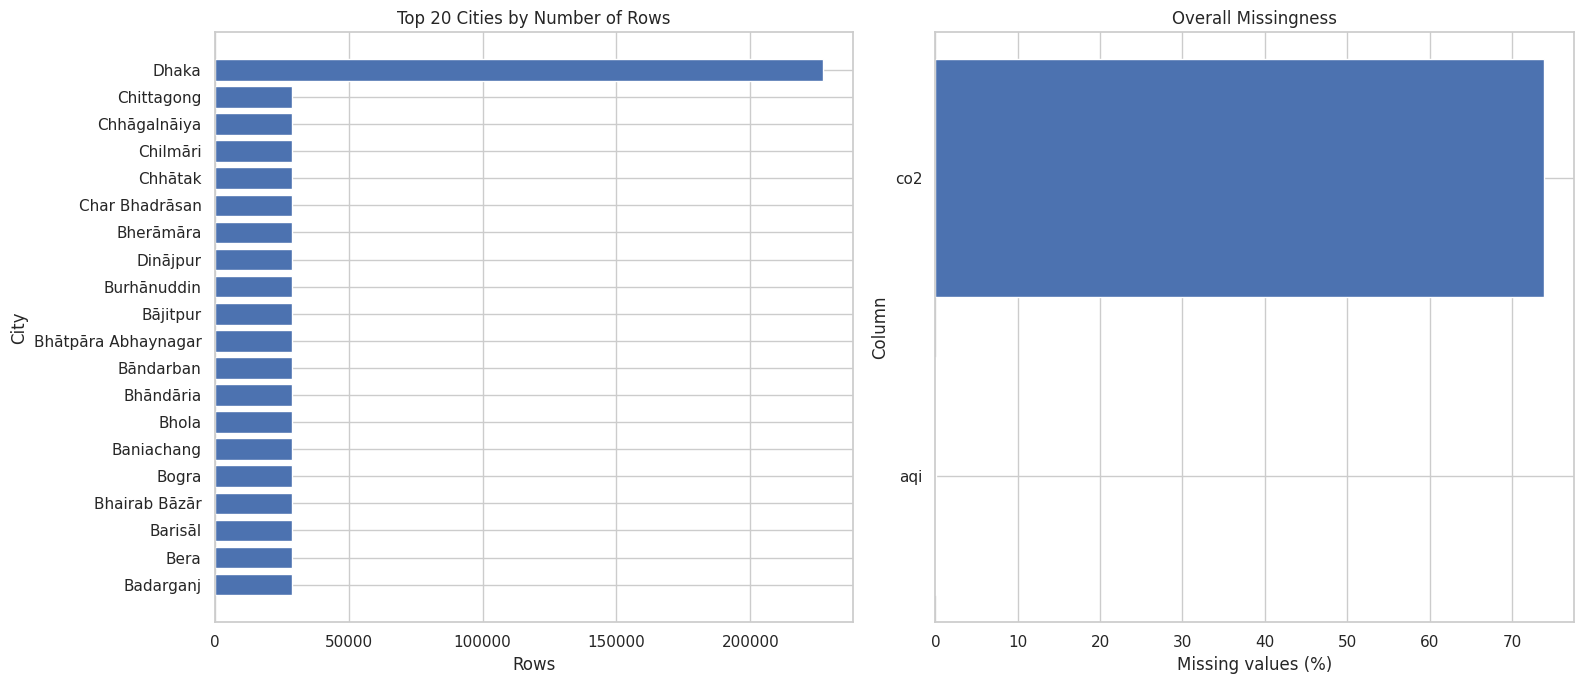

In [18]:
top_20_coverage = coverage.head(20).sort_values("row_count")
top_missing = missingness.loc[missingness["missing_percent"] > 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_20_coverage["city"], top_20_coverage["row_count"])
axes[0].set_title("Top 20 Cities by Number of Rows")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("City")

axes[1].barh(top_missing.index[::-1], top_missing["missing_percent"][::-1])
axes[1].set_title("Overall Missingness")
axes[1].set_xlabel("Missing values (%)")
axes[1].set_ylabel("Column")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_coverage_and_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

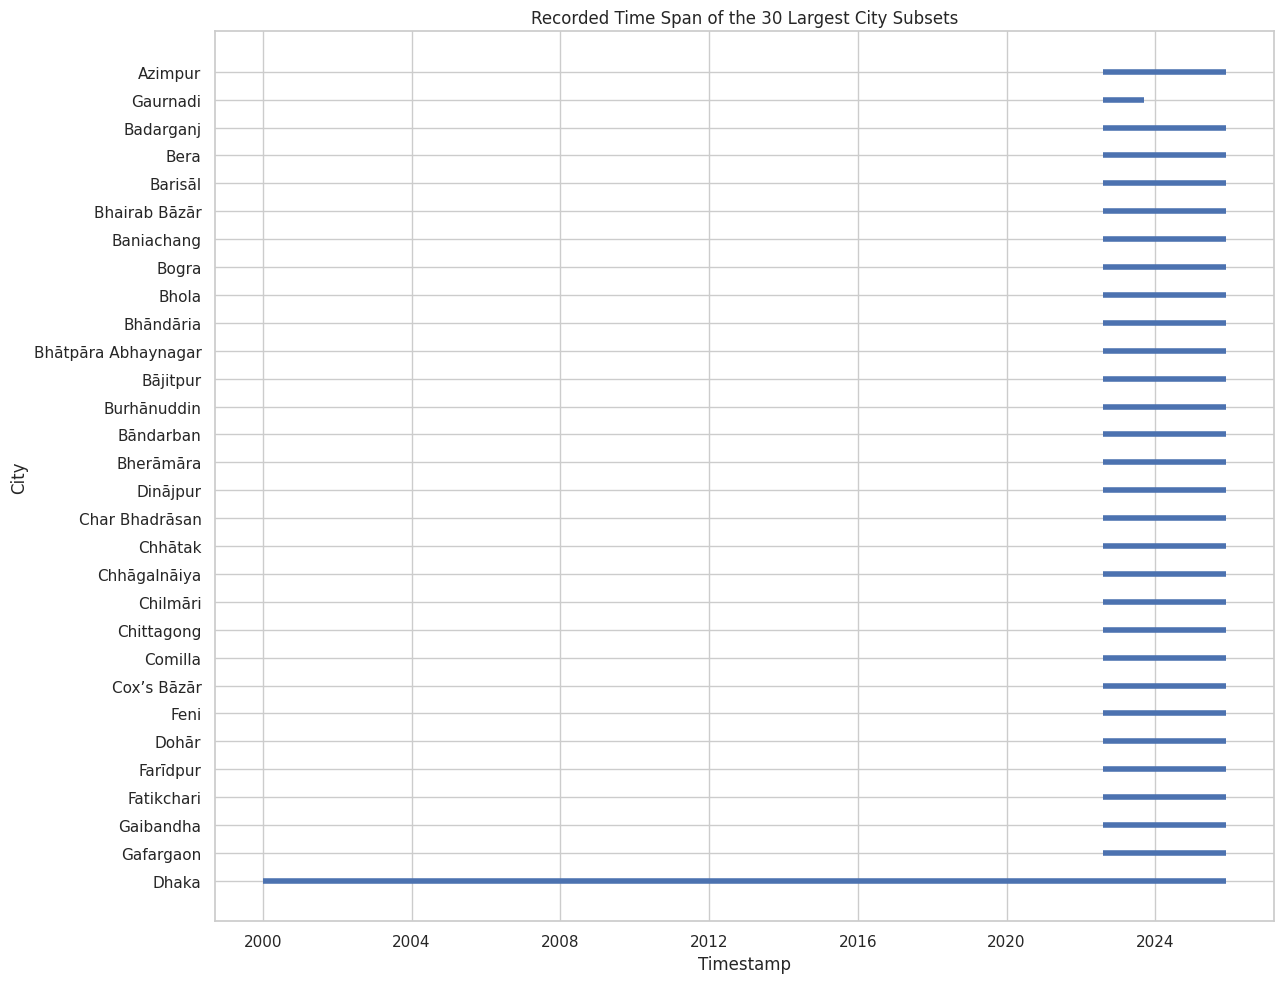

In [19]:
timeline = coverage.head(30).sort_values("first_timestamp").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))

for index, row in timeline.iterrows():
    ax.hlines(index, row["first_timestamp"], row["last_timestamp"], linewidth=4)

ax.set_yticks(range(len(timeline)))
ax.set_yticklabels(timeline["city"])
ax.set_title("Recorded Time Span of the 30 Largest City Subsets")
ax.set_xlabel("Timestamp")
ax.set_ylabel("City")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_city_coverage_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. AQI Distribution and Pollutant Relationships

This section performs an initial exploratory analysis of the numeric air-quality variables.

A reproducible sample of up to 100,000 rows is used to keep the visualizations efficient.

The section produces:

- A histogram of hourly AQI values
- Reference lines for the AQI 101+ and AQI 151+ thresholds
- A Spearman correlation heatmap for AQI and the available pollutants

Spearman correlation is used because pollutant measurements and AQI may have nonlinear relationships and extreme values. These correlations are descriptive only and do not establish which variables will be selected for modeling.

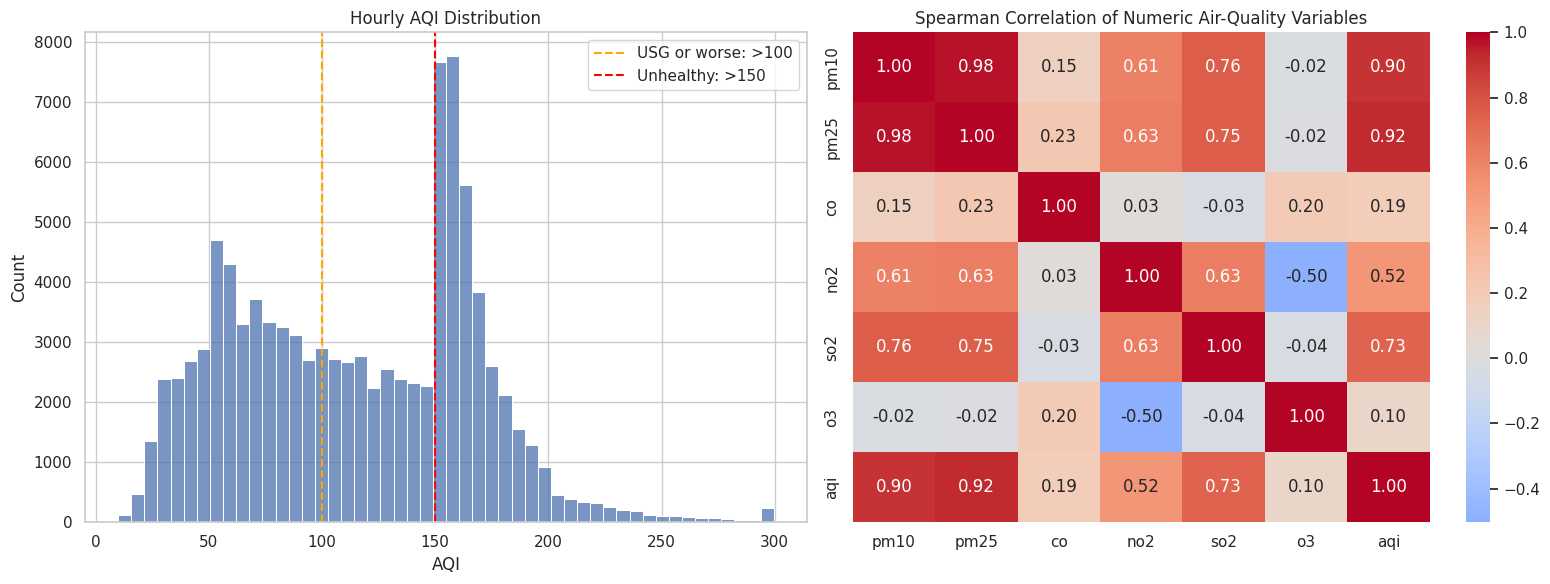

In [20]:
plot_columns = [
    column
    for column in ["pm10", "pm25", "co", "no2", "so2", "o3", "aqi"]
    if column in audit_valid.columns
]

sample_size = min(100_000, len(audit_valid))
eda_sample = audit_valid[plot_columns].sample(sample_size, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(eda_sample["aqi"].dropna(), bins=50, ax=axes[0])
axes[0].axvline(100, color="orange", linestyle="--", label="USG or worse: >100")
axes[0].axvline(150, color="red", linestyle="--", label="Unhealthy: >150")
axes[0].set_title("Hourly AQI Distribution")
axes[0].set_xlabel("AQI")
axes[0].legend()

correlation = eda_sample.corr(method="spearman")
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation of Numeric Air-Quality Variables")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_aqi_distribution_and_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Provisional Daily AQI and Target Balance

The final daily dataset will be created in Notebook 02. However, a provisional daily calculation is needed here to understand whether the proposed classification target is severely imbalanced.

For audit purposes, this section:

1. Groups observations by city and calendar day.
2. Uses the maximum provided hourly AQI as a provisional daily AQI.
3. Keeps days with at least 18 recorded hours and 18 valid AQI observations.
4. Calculates the percentage of days with:
   - AQI greater than 150, representing the main Unhealthy target
   - AQI greater than 100, representing USG or worse

These results are diagnostic only. They do not yet create the final target variable.

In [21]:
daily_diagnostic = (
    audit_valid.groupby(["city", "date"])
    .agg(
        daily_aqi=("aqi", "max"),
        unique_hours=("hour", "nunique"),
        valid_aqi_hours=("aqi", "count"),
    )
    .reset_index()
)

usable_daily_diagnostic = daily_diagnostic.loc[
    daily_diagnostic["unique_hours"].ge(MIN_HOURS_PER_DAY)
    & daily_diagnostic["valid_aqi_hours"].ge(MIN_HOURS_PER_DAY)
].copy()

usable_daily_diagnostic["unhealthy_151_plus"] = usable_daily_diagnostic["daily_aqi"].gt(150)
usable_daily_diagnostic["usg_or_worse_101_plus"] = usable_daily_diagnostic["daily_aqi"].gt(100)

threshold_summary = (
    usable_daily_diagnostic.groupby("city")
    .agg(
        usable_days=("date", "nunique"),
        unhealthy_days_151_plus=("unhealthy_151_plus", "sum"),
        unhealthy_rate_151_plus=("unhealthy_151_plus", "mean"),
        usg_or_worse_days_101_plus=("usg_or_worse_101_plus", "sum"),
        usg_or_worse_rate_101_plus=("usg_or_worse_101_plus", "mean"),
    )
    .reset_index()
)

threshold_summary["unhealthy_rate_151_plus"] *= 100
threshold_summary["usg_or_worse_rate_101_plus"] *= 100

threshold_summary = threshold_summary.sort_values(
    "unhealthy_rate_151_plus",
    ascending=False,
)

display(threshold_summary.head(25))
threshold_summary.to_csv(AUDIT_DIR / "provisional_threshold_summary.csv", index=False)

,city,usable_days,unhealthy_days_151_plus,unhealthy_rate_151_plus,usg_or_worse_days_101_plus,usg_or_worse_rate_101_plus
21,Dhaka,9458,8795,92.990061,9039,95.569888
6,Bherāmāra,1207,660,54.681027,885,73.322287
10,Bogra,1207,599,49.627175,888,73.570837
0,Azimpur,1207,563,46.644573,788,65.285833
22,Dinājpur,1207,540,44.739022,889,73.653687
5,Bhairab Bāzār,1207,538,44.573322,793,65.700083
4,Bera,1207,506,41.922121,797,66.031483
9,Bhātpāra Abhaynagar,1207,506,41.922121,757,62.717481
14,Char Bhadrāsan,1207,475,39.353770,698,57.829329
1,Badarganj,1207,474,39.270920,835,69.179785


## 15. Dhaka Overlap and Candidate-City Selection

The project will use Dhaka and 2–4 non-Dhaka cities. Cities must be selected using data availability rather than pollution level, because selecting cities based on the target could bias the study.

This section evaluates each city using:

- Number of observed days
- Median recorded hours per day
- AQI completeness
- Temporal overlap with Dhaka
- Hourly coverage
- Number of complete usable years
- Provisional unhealthy-day prevalence

A city is initially considered eligible if it has:

- At least 365 observed days
- At least 365 usable days overlapping with Dhaka
- A median of at least 18 recorded hours per day
- At least 80% non-missing AQI observations

The code then recommends up to four non-Dhaka cities using a greedy procedure that preserves the largest common set of usable dates across all selected cities. The final choice still requires approval from both team members.

In [22]:
DHAKA_NAME = "Dhaka"

city_names = sorted(audit_valid["city"].dropna().unique())
city_lookup = {str(city).casefold(): city for city in city_names}

if DHAKA_NAME.casefold() not in city_lookup:
    possible_matches = [
        city for city in city_names
        if "dhaka" in str(city).casefold()
    ]

    print("Possible Dhaka matches:", possible_matches)
    raise ValueError("Update DHAKA_NAME to the exact dataset spelling.")

dhaka_city = city_lookup[DHAKA_NAME.casefold()]

usable_date_sets = {
    city: set(group["date"])
    for city, group in usable_daily_diagnostic.groupby("city")
}

dhaka_dates = usable_date_sets.get(dhaka_city, set())

selection_table = coverage.merge(gap_summary, on="city", how="left")
selection_table = selection_table.merge(seasonality_summary, on="city", how="left")
selection_table = selection_table.merge(threshold_summary, on="city", how="left")

selection_table["overlap_days_with_dhaka"] = selection_table["city"].map(
    lambda city: len(usable_date_sets.get(city, set()) & dhaka_dates)
)

MIN_OBSERVED_DAYS = 365
MIN_DHAKA_OVERLAP_DAYS = 365
MIN_MEDIAN_HOURS = 18
MIN_AQI_COMPLETENESS = 80

selection_table["eligible"] = (
    selection_table["observed_days"].ge(MIN_OBSERVED_DAYS)
    & selection_table["overlap_days_with_dhaka"].ge(MIN_DHAKA_OVERLAP_DAYS)
    & selection_table["median_unique_hours_per_day"].ge(MIN_MEDIAN_HOURS)
    & selection_table["aqi_non_missing_percent"].ge(MIN_AQI_COMPLETENESS)
)

selection_table = selection_table.sort_values(
    [
        "eligible",
        "overlap_days_with_dhaka",
        "hourly_coverage_percent",
        "aqi_non_missing_percent",
    ],
    ascending=False,
)

selection_columns = [
    "city",
    "eligible",
    "row_count",
    "observed_days",
    "overlap_days_with_dhaka",
    "median_unique_hours_per_day",
    "hourly_coverage_percent",
    "aqi_non_missing_percent",
    "complete_usable_years",
    "unhealthy_rate_151_plus",
]

display(selection_table[selection_columns].head(25))
selection_table.to_csv(AUDIT_DIR / "city_selection_candidates.csv", index=False)

,city,eligible,row_count,observed_days,overlap_days_with_dhaka,median_unique_hours_per_day,hourly_coverage_percent,aqi_non_missing_percent,complete_usable_years,unhealthy_rate_151_plus
0,Dhaka,True,227016,9459,9458,24.0,99.989870,99.989428,25,92.990061
1,Badarganj,True,28992,1208,1207,24.0,99.920731,99.917219,2,39.270920
2,Bera,True,28992,1208,1207,24.0,99.920731,99.917219,2,41.922121
3,Barisāl,True,28992,1208,1207,24.0,99.920731,99.917219,2,34.134217
4,Bhairab Bāzār,True,28992,1208,1207,24.0,99.920731,99.917219,2,44.573322
5,Baniachang,True,28992,1208,1207,24.0,99.920731,99.917219,2,30.903065
6,Bogra,True,28992,1208,1207,24.0,99.920731,99.917219,2,49.627175
7,Bhola,True,28992,1208,1207,24.0,99.920731,99.917219,2,28.086164
8,Bhāndāria,True,28992,1208,1207,24.0,99.920731,99.917219,2,32.477216
9,Bhātpāra Abhaynagar,True,28992,1208,1207,24.0,99.920731,99.917219,2,41.922121


In [23]:
eligible_cities = selection_table.loc[
    selection_table["eligible"]
    & selection_table["city"].ne(dhaka_city),
    "city",
].tolist()

recommended_cities = [dhaka_city]
common_dates = set(dhaka_dates)

while len(recommended_cities) < 5 and eligible_cities:
    overlap_scores = {
        city: len(common_dates & usable_date_sets.get(city, set()))
        for city in eligible_cities
    }

    best_city = max(overlap_scores, key=overlap_scores.get)
    best_common_days = overlap_scores[best_city]

    if best_common_days < MIN_DHAKA_OVERLAP_DAYS:
        break

    recommended_cities.append(best_city)
    common_dates &= usable_date_sets[best_city]
    eligible_cities.remove(best_city)

print("Recommended cities:", recommended_cities)
print("Common usable dates:", len(common_dates))

if common_dates:
    print("First common date:", min(common_dates))
    print("Last common date:", max(common_dates))

if len(recommended_cities) < 3:
    print("WARNING: Fewer than three cities passed the current eligibility rules.")
    print("Review the thresholds, coverage, and faculty expectations before continuing.")

Recommended cities: ['Dhaka', 'Badarganj', 'Bera', 'Barisāl', 'Bhairab Bāzār']
Common usable dates: 1207
First common date: 2022-08-05 00:00:00
Last common date: 2025-11-23 00:00:00


## 16. Diagnostic Comparison of Recommended Cities

This section visualizes the cities recommended by the coverage audit.

It produces:

- A time-series plot of provisional daily maximum AQI
- A comparison of the percentage of usable days with AQI greater than 150

These figures help reveal differences in temporal coverage, AQI behaviour, and class balance. They are exploratory diagnostics and should not be interpreted as final modeling results.

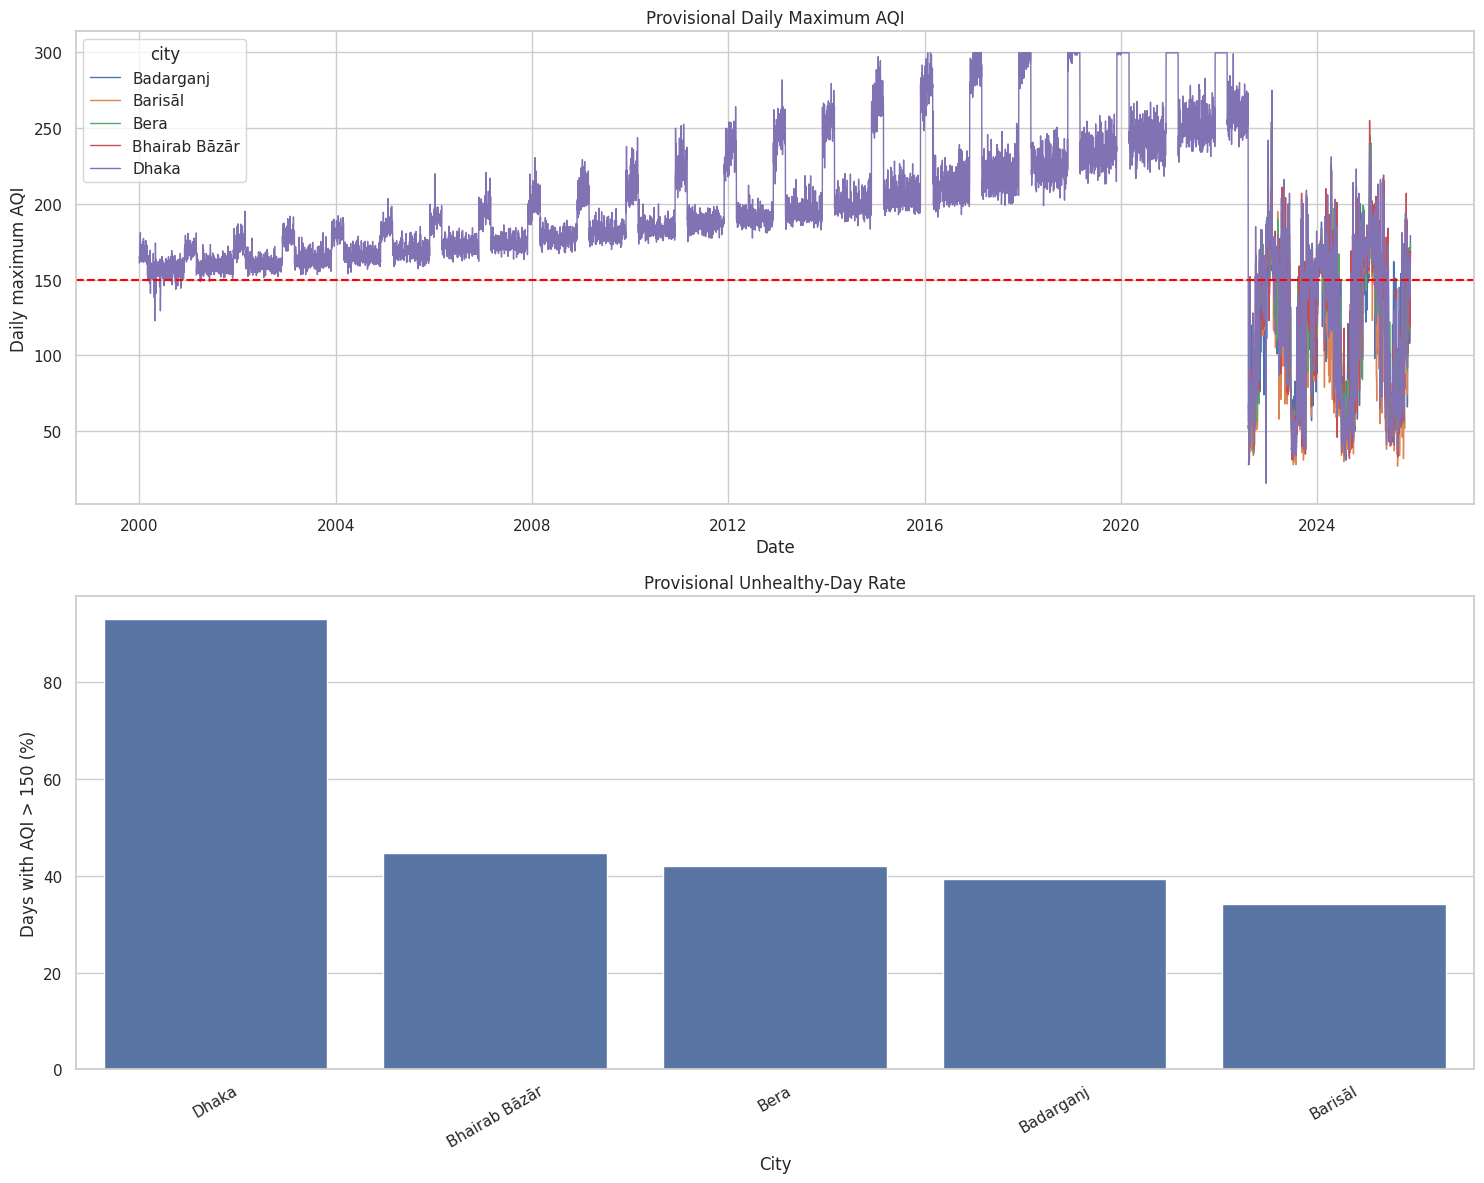

In [24]:
recommended_daily = usable_daily_diagnostic.loc[
    usable_daily_diagnostic["city"].isin(recommended_cities)
].copy()

recommended_thresholds = threshold_summary.loc[
    threshold_summary["city"].isin(recommended_cities)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.lineplot(
    data=recommended_daily,
    x="date",
    y="daily_aqi",
    hue="city",
    linewidth=1,
    ax=axes[0],
)

axes[0].axhline(150, color="red", linestyle="--", label="Unhealthy threshold")
axes[0].set_title("Provisional Daily Maximum AQI")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily maximum AQI")

sns.barplot(
    data=recommended_thresholds,
    x="city",
    y="unhealthy_rate_151_plus",
    ax=axes[1],
)

axes[1].set_title("Provisional Unhealthy-Day Rate")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Days with AQI > 150 (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_recommended_city_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Audit Summary and Output Files

This section combines the main audit findings into a structured summary.

The saved `audit_summary.json` records:

- Source-file details and checksum
- Dataset dimensions
- Number of cities
- Overall timestamp range
- Duplicate counts
- Distance from Excel's row limit
- Equivalent coverage per city
- Recommended cities
- Common usable period
- Seasonality decision
- Proposed daily AQI and target definitions
- Timestamp interpretation warning

The final code cell lists every saved audit table and figure so that the team can confirm that all expected outputs were created successfully.

In [25]:
selected_seasonality = seasonality_summary.loc[
    seasonality_summary["city"].isin(recommended_cities)
]

seasonality_supported_for_all = bool(
    len(selected_seasonality) == len(recommended_cities)
    and selected_seasonality["seasonality_supported"].all()
)

audit_summary = {
    "source_file": RAW_FILE.name,
    "file_size_mb": round(file_size_mb, 2),
    "sha256": file_checksum,
    "rows": int(len(audit)),
    "columns": int(audit.shape[1]),
    "cities": int(actual_cities),
    "minimum_timestamp": str(audit_valid["timestamp"].min()),
    "maximum_timestamp": str(audit_valid["timestamp"].max()),
    "exact_duplicate_rows": exact_duplicate_rows,
    "duplicate_city_timestamp_pairs": duplicate_city_timestamps,
    "rows_below_excel_data_limit": int(distance_from_excel_limit),
    "equivalent_complete_years_per_city": round(equivalent_years_per_city, 3),
    "recommended_cities": recommended_cities,
    "common_usable_days": int(len(common_dates)),
    "common_first_date": str(min(common_dates)) if common_dates else None,
    "common_last_date": str(max(common_dates)) if common_dates else None,
    "seasonality_supported_for_all_recommended_cities": seasonality_supported_for_all,
    "provisional_daily_aqi_aggregation": "Maximum provided hourly AQI",
    "main_target": "Next calendar day's daily AQI > 150",
    "excluded_future_predictor": "CO2",
    "timestamp_note": "Parsed with utc=True for this audit; confirm the source timezone before final daily aggregation.",
}

with (AUDIT_DIR / "audit_summary.json").open("w", encoding="utf-8") as file:
    json.dump(audit_summary, file, indent=2)

print(json.dumps(audit_summary, indent=2))

{
  "source_file": "AQI Bangladesh.csv",
  "file_size_mb": 93.75,
  "sha256": "8760175fc048eea4180b828fd60d10cb799a73a5144a7e4aca19ddbaf8dbdd62",
  "rows": 1048551,
  "columns": 14,
  "cities": 30,
  "minimum_timestamp": "2000-01-01 00:00:00+00:00",
  "maximum_timestamp": "2025-11-23 23:00:00+00:00",
  "exact_duplicate_rows": 0,
  "duplicate_city_timestamp_pairs": 0,
  "rows_below_excel_data_limit": 24,
  "equivalent_complete_years_per_city": 3.987,
  "recommended_cities": [
    "Dhaka",
    "Badarganj",
    "Bera",
    "Baris\u0101l",
    "Bhairab B\u0101z\u0101r"
  ],
  "common_usable_days": 1207,
  "common_first_date": "2022-08-05 00:00:00",
  "common_last_date": "2025-11-23 00:00:00",
  "seasonality_supported_for_all_recommended_cities": true,
  "provisional_daily_aqi_aggregation": "Maximum provided hourly AQI",
  "main_target": "Next calendar day's daily AQI > 150",
  "excluded_future_predictor": "CO2",
  "timestamp_note": "Parsed with utc=True for this audit; confirm the source t

In [26]:
print("Saved audit files:")

for file in sorted(AUDIT_DIR.iterdir()):
    print("-", file.name)

print("\nSaved figures:")

for file in sorted(FIGURES_DIR.iterdir()):
    print("-", file.name)

Saved audit files:
- audit_summary.json
- city_coverage_summary.csv
- city_gap_summary.csv
- city_selection_candidates.csv
- missingness_by_city.csv
- monthly_coverage.csv
- overall_missingness.csv
- provisional_threshold_summary.csv
- seasonality_summary.csv

Saved figures:
- 01_coverage_and_missingness.png
- 02_city_coverage_timeline.png
- 03_aqi_distribution_and_correlation.png
- 04_recommended_city_diagnostics.png


## Audit-gate decision

### Verified dataset facts

- Actual rows:
- Actual columns:
- Number of cities:
- Overall minimum timestamp:
- Overall maximum timestamp:
- Distance from the Excel data-row limit:
- Evidence supporting or rejecting possible truncation:

### Selected scope

- Selected cities:
- Common study period:
- Common usable days:
- Reason each city was selected:

### Data-quality decisions

- Duplicate handling required:
- Invalid-value handling required:
- Missingness concerns:
- Timestamp/timezone interpretation:
- CO2 will be excluded: **Yes**

### Seasonality decision

- Number of complete usable years per selected city:
- Is seasonal analysis defensible?
- Final decision and justification:

### Target decision

- Daily AQI aggregation: proposed maximum provided hourly AQI
- Main positive class: next calendar day's daily AQI > 150
- Optional sensitivity analysis: next calendar day's daily AQI > 100
- Final approved definition:

### Audit gate

- [ ] Actual coverage verified
- [ ] Possible truncation investigated
- [ ] Three to five cities approved
- [ ] Common period approved
- [ ] Seasonal-analysis decision recorded
- [ ] Daily AQI definition approved
- [ ] Target threshold approved

**Notebook 02 must not begin until every item above is completed.**